<div style="text-align: center;">

# Trackpy: Particle Tracking and Diffusion Analysis

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

**Data**: Microscopy videos of micron-sized particles undergoing Brownian motion in bulk water, obtained from https://github.com/soft-matter/trackpy-examples.

**See also**: Crocker, J. C., & Grier, D. G. (1996). Methods of Digital Video Microscopy for Colloidal Studies. *J. Colloid Interf. Sci.*, 179(1), 298–310. http://doi.org/10.1006/jcis.1996.0217

---

## Overview

This notebook demonstrates how to extract quantitative physical information from microscopy video of a colloidal suspension using the **Trackpy** library, a Python implementation of the Crocker–Grier particle-tracking algorithm. The analysis connects classical image processing (feature localization) to statistical mechanics (Brownian motion and fluid viscosity).

### Relevance to Electrochemical Imaging

Particle tracking techniques are directly applicable to electrochemical systems where the dynamics of particles, dendrites, or electrolyte interfaces are observed over time. The same pipeline — detect → link → analyze trajectories — can be applied to time-lapse electron microscopy or optical microscopy data of battery electrode dissolution, deposition, or colloidal probe rheology.

### Workflow

1. **Feature localization**: detect bright particles in each frame using a bandpass filter and centroid estimation.
2. **Quality filtering**: remove low-mass (noise) detections using histogram-guided thresholds.
3. **Subpixel bias check**: verify centroid accuracy and select an appropriate mask size.
4. **Batch localization**: apply detection across all frames to produce a time-resolved position dataset.
5. **Trajectory linking**: connect per-frame positions into continuous particle paths.
6. **Drift correction**: estimate and subtract ensemble drift to isolate Brownian motion.
7. **MSD analysis**: compute individual and ensemble mean-squared displacements.
8. **Viscosity estimation**: fit a power law to the ensemble MSD and apply the Stokes–Einstein relation.


### Visualization Style and Intensity Representation


This cell configures the plotting backend and grayscale display parameters to ensure that particle images are rendered with consistent contrast and spatial scale, which is essential for visually assessing feature sharpness and noise levels.
By standardising the colormap and figure geometry, we make qualitative inspections of particle images more reproducible, supporting robust choices of localization parameters later in the analysis.

In [1]:
import sys
import os
from pathlib import Path
import pims
import trackpy as tp
import matplotlib as mpl
import matplotlib.pyplot as plt
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(message)s",
    datefmt="%d:%m:%Y %H:%M:%S",
)

In [2]:
try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()
cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent
if repo_root is None:
    repo_root = Path.cwd()
modules_path = str(repo_root / 'src')
if modules_path not in sys.path:
    sys.path.insert(0, modules_path)
print(f'Added src path to sys.path: {modules_path}')

Added modules path to sys.path: /Users/amir/GIT_repositories/DPG2026_release/modules


### Embedding Experimental Context in Image Data


Inspecting metadata attached to individual frames illustrates how imaging conditions and instrument settings can be carried alongside intensity data, effectively augmenting each trajectory with rich experimental annotations.
This enables more nuanced analyses, such as correlating changes in particle dynamics with alterations in acquisition parameters or environmental conditions.

In [3]:
@pims.pipeline
def gray(image):
    return image[:, :, 1]  # Take just the green channel

data_dir = os.path.join(repo_root, "Train_test_images", "bulk_water")
frames = gray(pims.open(os.path.join(data_dir, '*.png')))

### Initial Feature Localization in a Single Frame


Here we apply a convolution-based localization algorithm to identify candidate particle centers in a single micrograph, given an expected feature size and contrast polarity.
This step transforms the continuous intensity field into a discrete point pattern, serving as the foundational measurement from which trajectories and transport statistics will be inferred.

In [4]:
f = tp.locate(frames[0], 11, invert=True)

### Feature Population Statistics


By inspecting the distribution of feature mass values, this cell characterizes the population of detected peaks in terms of brightness, which serves as a proxy for particle size and focus quality.
Such histograms guide principled thresholding decisions that separate genuine particles from noise-induced artefacts, thereby improving both the accuracy and efficiency of subsequent tracking.

In [5]:
f.head()  # shows the first few rows of data

,y,x,mass,size,ecc,signal,raw_mass,ep,frame
0,4.750000,103.668564,192.862485,2.106615,0.066390,10.808405,10714.0,0.073666,0
1,5.249231,585.779487,164.659302,2.962674,0.078936,4.222033,10702.0,0.075116,0
2,5.785986,294.792544,244.624615,2.244542,0.219217,15.874846,10686.0,0.077141,0
3,5.869369,338.173423,187.458282,2.046201,0.185333,13.088304,10554.0,0.099201,0
4,6.746377,310.584169,151.486558,3.103294,0.053342,4.475355,10403.0,0.147430,0


### Visual Validation of Detected Features


Overlaying annotated feature markers on the original frame allows rapid visual assessment of whether the localization algorithm is correctly identifying particle centroids and rejecting background fluctuations.
This qualitative validation step is essential before scaling up to batch processing, as systematic mis-localization can otherwise contaminate the entire trajectory dataset.

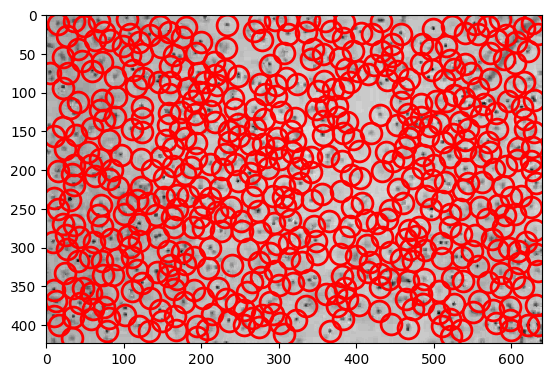

In [6]:
tp.annotate(f, frames[0]);

### Mass-Based Filtering of Candidate Particles


This cell constructs a brightness (mass) histogram for the initial set of localized features, providing an empirical basis for selecting a minimum mass threshold that suppresses noise while retaining true particles.
Interpreting this distribution is a key step in defining a robust observation model, because it separates signal-dominated regions of intensity space from those dominated by camera and background fluctuations.

[Text(0.5, 0, 'mass'), Text(0, 0.5, 'count')]

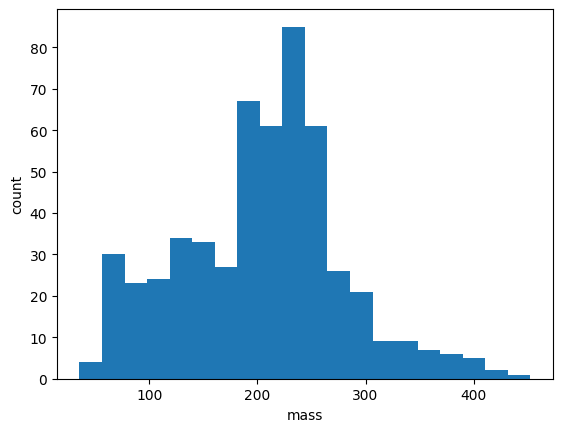

In [7]:
fig, ax = plt.subplots()
ax.hist(f['mass'], bins=20)

# Optionally, label the axes.
ax.set(xlabel='mass', ylabel='count')

### Applying the Minimum-Mass Threshold

Armed with the mass histogram from the previous step, we now re-run feature localization with a `minmass=20` constraint. This threshold eliminates low-intensity detections — likely noise or out-of-focus objects — keeping only features bright enough to represent genuine colloidal particles.

The remaining feature set is then overlaid on the raw frame to confirm that the chosen threshold retains real particles while discarding spurious detections.


In [8]:
f = tp.locate(frames[0], 11, invert=True, minmass=20)

### Refined Feature Localization with Intensity Thresholding
Repeating localization with a `minmass` constraint implements a physically motivated filter that preferentially retains well-defined particle images while discarding low-intensity artefacts.
This refinement sharpens the correspondence between detected features and actual colloidal particles, thereby improving the fidelity of downstream trajectory linking and diffusion analysis.

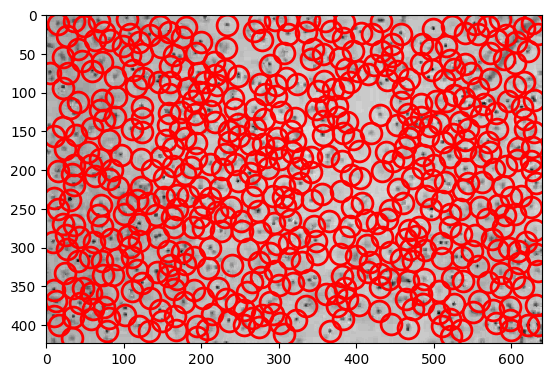

In [9]:
tp.annotate(f, frames[0]);

### Post-Filtering Visual Sanity Check
After applying stricter selection criteria, this cell overlays the surviving features on the raw frame to verify that the filtering process has preserved genuine particles while eliminating spurious detections.
Such iterative visual checks provide empirical feedback connecting numerical thresholds to physically meaningful particle populations.

/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/trackpy/plots.py:643: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  axlist = f[pos_columns].applymap(lambda x: x % 1).hist()


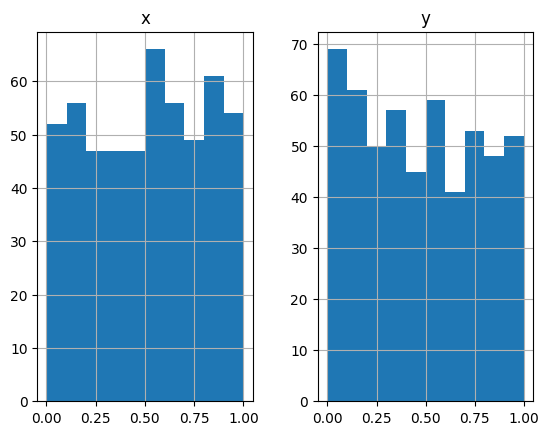

In [10]:
tp.subpx_bias(f);

### Subpixel Accuracy Diagnostics
This cell assesses the subpixel localization quality by examining whether the fractional parts of feature coordinates are uniformly distributed, as expected for unbiased centroid estimation.
Deviations from uniformity reveal systematic biases introduced by inappropriate mask sizes or image preprocessing, which can otherwise propagate into underestimated or overestimated diffusion coefficients.

/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/trackpy/plots.py:643: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  axlist = f[pos_columns].applymap(lambda x: x % 1).hist()


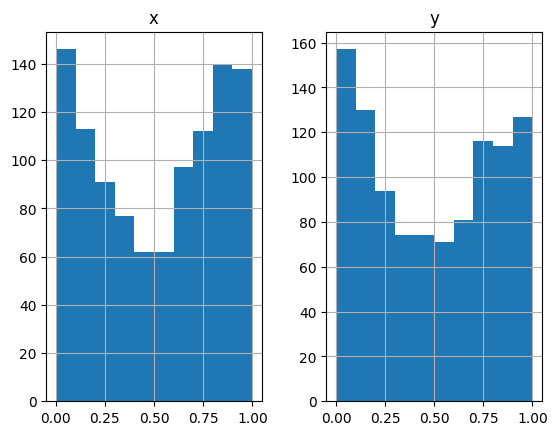

In [11]:
tp.subpx_bias(tp.locate(frames[0], 7, invert=True, minmass=20));

### Effect of Mask Size on Localization Bias
By repeating the subpixel-bias check with a smaller mask, this cell empirically demonstrates how insufficient spatial support leads to systematic localization errors, often visible as dips or peaks in the fractional coordinate histograms.
This analysis links an algorithmic hyperparameter (mask size) to statistical properties of the estimator, guiding principled parameter choices for accurate particle-tracking experiments.

In [12]:
f = tp.batch(frames[:300], 11, minmass=20, invert=True);

Frame 299: 624 features


### Batch Localization Across Time
This step extends feature detection from a single frame to a time series, applying identical localization parameters across many images to obtain a temporally resolved cloud of particle coordinates.
The resulting dataset forms the raw material for building trajectories, effectively sampling the stochastic dynamics of the colloidal suspension at discrete time intervals.

In [13]:
# tp.quiet()  # Turn off progress reports for best performance
t = tp.link(f, 5, memory=3)

Frame 299: 624 trajectories present.


### Trajectory Construction via Probabilistic Linking
Here we convert sets of per-frame particle positions into continuous trajectories by linking detections across time under constraints on maximum frame-to-frame displacement and allowed gaps.
This operation effectively infers the most plausible Lagrangian paths consistent with the observed positions, transforming static snapshots into time-resolved motion suitable for Brownian and transport analyses.

In [14]:
t.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
0,4.750000,103.668564,192.862485,2.106615,0.066390,10.808405,10714.0,0.073666,0,0
365,284.118980,25.313881,149.037779,2.321961,0.031799,7.008575,10770.0,0.067577,0,1
364,282.753601,534.788476,222.754482,1.908443,0.103416,15.874846,10415.0,0.141946,0,2
363,280.010398,275.185353,186.782757,2.508665,0.183181,7.261897,10438.0,0.132499,0,3
362,279.134153,252.780324,151.064355,2.938060,0.253812,4.306474,10359.0,0.171764,0,4


### Tabular Representation of Trajectories
Inspecting the head of the trajectory DataFrame shows how each observation combines spatial coordinates, frame index, and particle identifier into a unified structure.
This representation is central for statistical mechanics analyses, allowing ensemble averages, correlation functions, and transport coefficients to be computed from many individual stochastic paths.

In [15]:
t1 = tp.filter_stubs(t, 25)
# Compare the number of particles in the unfiltered and filtered data.
print('Before:', t['particle'].nunique())
print('After:', t1['particle'].nunique())

Before: 13715
After: 1505


### Elimination of Ephemeral Trajectories
Filtering out short-lived tracks focuses the analysis on particles that are observed over sufficiently long time windows to yield reliable diffusion statistics.
This step reduces the impact of noise-induced or transient detections, aligning the effective sampling of trajectories with the assumptions underlying mean-squared displacement and viscosity estimation.

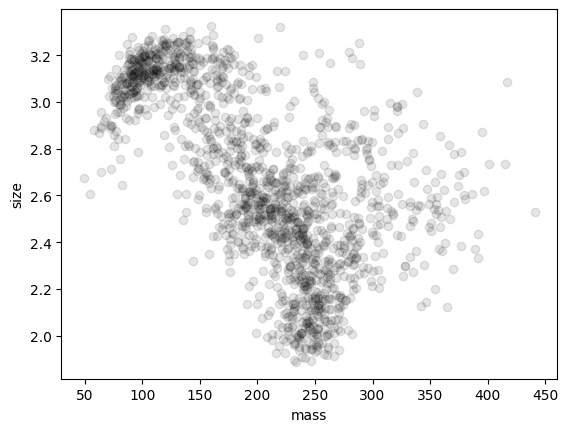

In [16]:
plt.figure()
tp.mass_size(t1.groupby('particle').mean()); # convenience function -- just plots size vs. mass

### Appearance Statistics in Trajectory Space
By plotting average mass versus apparent size for each trajectory, this cell characterizes the ensemble of tracked particles in a morphological feature space.
This joint distribution helps distinguish well-behaved single particles from aggregates or out-of-focus objects, guiding additional filtering that ensures only physically meaningful probes contribute to the final rheological measurements.

In [17]:
t2 = t1[((t1['mass'] > 50) & (t1['size'] < 2.6) &
         (t1['ecc'] < 0.3))]

### Morphology-Based Selection of Probes
Here we restrict the trajectory set to particles occupying a chosen region of the mass–size–eccentricity space, effectively enforcing assumptions about approximate monodispersity and near-spherical shape.
This selection yields a subset of probes whose dynamics are most representative of the intended colloidal population, improving the interpretability of subsequent diffusion and viscosity estimates.

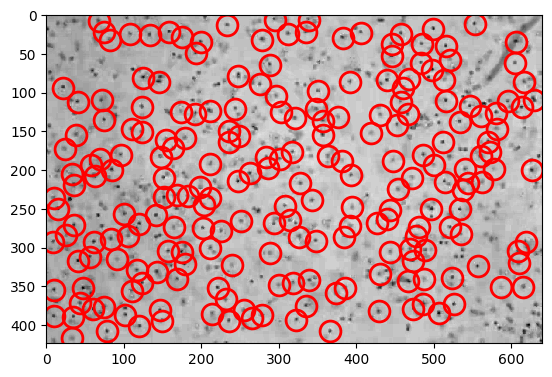

In [18]:
plt.figure()
tp.annotate(t2[t2['frame'] == 0], frames[0]);

### Spatial Distribution of Selected Particles
Overlaying only the morphology-filtered particles on the first frame provides a final visual check that the chosen selection region indeed isolates well-focused, single particles distributed throughout the field of view.
This ensures that the probes used for Brownian motion analysis are both physically representative and free from obvious imaging artefacts.

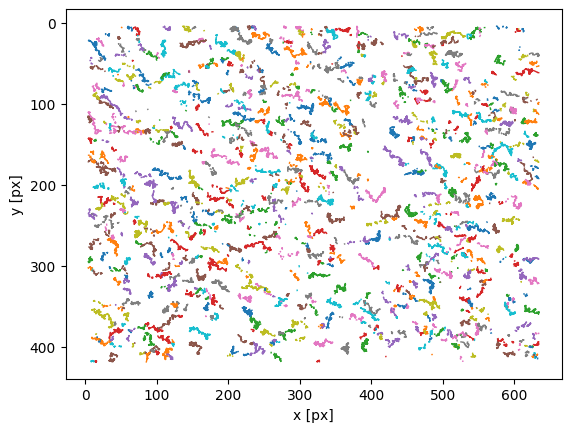

In [19]:
plt.figure()
tp.plot_traj(t2);

### Trajectory Geometry in the Laboratory Frame
Plotting particle tracks over time reveals the raw geometry of motion, including both random fluctuations and any systematic drift of the ensemble.
This visualization provides an intuitive link between statistical diffusion descriptions and the actual paths traversed by individual colloids in the imaged volume.

In [20]:
d = tp.compute_drift(t2)

### Estimation of Ensemble Drift
Computing the ensemble-averaged displacement as a function of time isolates any coherent drift of the colloidal population due to flows, stage motion, or other systematic effects.
Separating this drift from random motion is essential to avoid biasing diffusion and viscosity estimates, effectively decomposing motion into deterministic and stochastic components.

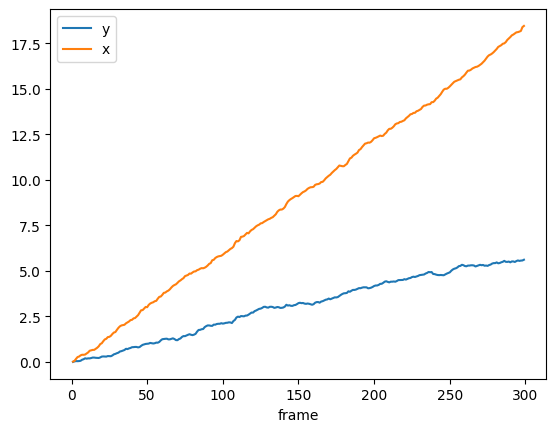

In [21]:
d.plot()
plt.show()

### Drift Trajectory in Physical Coordinates
Plotting the drift vector as a function of time makes the deterministic component of motion explicit, clarifying whether there is a net flow, stage creep, or other slow systematic displacement of the observation window.
Understanding this component allows one to disentangle fluid rheology from experimental artefacts when interpreting particle trajectories.

In [22]:
tm = tp.subtract_drift(t2.copy(), d)

### Transformation to the Co-Moving Frame
Subtracting the estimated drift from each trajectory redefines motion in a reference frame moving with the ensemble average, leaving primarily stochastic Brownian fluctuations.
This co-moving frame is the natural setting for comparing observed dynamics to theoretical predictions such as the Stokes–Einstein relation for diffusive transport.

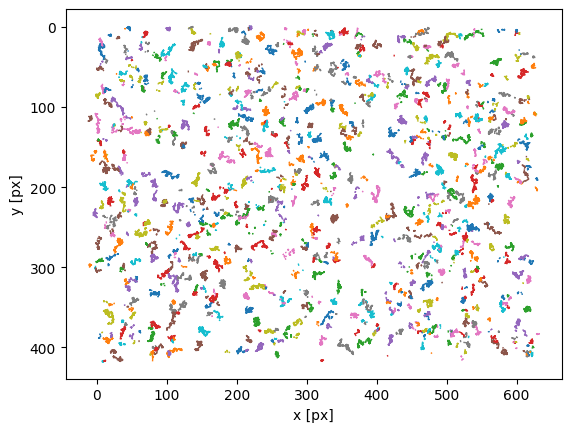

In [23]:
ax = tp.plot_traj(tm)
plt.show()

### Random Walks After Drift Removal
Replotting trajectories in the drift-subtracted frame reveals random-walk-like paths that are more directly comparable to ideal Brownian motion models.
Such visualizations provide an intuitive confirmation that the residual motion is isotropic and memoryless on the timescales of interest, validating subsequent diffusion analyses.

In [24]:
im = tp.imsd(tm, 100/285., 24)  # microns per pixel = 100/285., frames per second = 24

### Single-Particle Mean-Squared Displacement (MSD)
This cell computes the MSD for each trajectory as a function of lag time, quantifying how far individual particles wander on average over different temporal scales.
These curves are the primary bridge between raw trajectory data and continuum transport parameters, revealing whether motion is diffusive, subdiffusive, or ballistic in the observed regime.

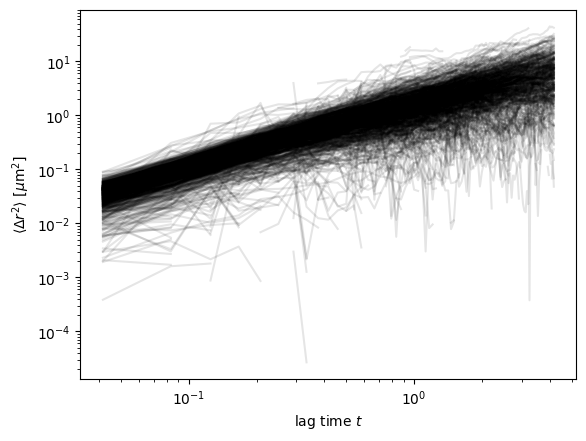

In [25]:
fig, ax = plt.subplots()
ax.plot(im.index, im, 'k-', alpha=0.1)  # black lines, semitransparent
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.set_xscale('log')
ax.set_yscale('log')

### Log–Log Visualization of Single-Particle MSD
Plotting the MSD of individual probes on log–log axes reveals both the power-law scaling and the spread of dynamical behaviours across particles.
This representation allows rapid visual assessment of whether the ensemble is consistent with simple Brownian motion (slope near 1) or exhibits anomalous diffusion due to confinement, interactions, or viscoelasticity.

In [26]:
em = tp.emsd(tm, 100/285., 24) # microns per pixel = 100/285., frames per second = 24

### Ensemble Mean-Squared Displacement (EMSD)
Aggregating displacements across all particles yields an ensemble-averaged MSD, which reduces trajectory-to-trajectory variability and better reflects the bulk transport properties of the medium.
This EMSD is the central observable used to extract a single effective diffusion coefficient and, via the Stokes–Einstein relation, an estimate of the fluid viscosity.

### Log–Log Visualization of the Ensemble MSD

Plotting the ensemble MSD on log–log axes makes the power-law scaling immediately visible. For purely Brownian (Fickian) diffusion in a Newtonian fluid, the expected slope is 1, corresponding to linear growth of mean-squared displacement with lag time. Deviations from slope 1 indicate subdiffusion (slope < 1, e.g., crowded or viscoelastic environments) or superdiffusion (slope > 1, e.g., active or driven motion).

The axis limits are set to highlight the relevant range of the EMSD curve, and the log–log representation compresses the wide dynamic range into a format amenable to linear regression for extracting the diffusion coefficient and anomalous exponent.


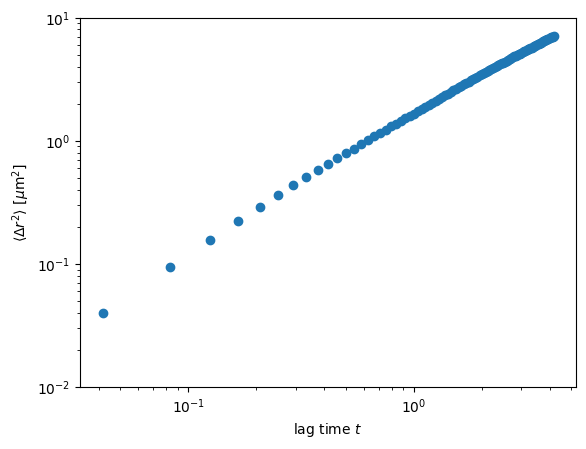

In [27]:
fig, ax = plt.subplots()
ax.plot(em.index, em, 'o')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set(ylabel=r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]',
       xlabel='lag time $t$')
ax.set(ylim=(1e-2, 10));

### 6.6 Power-law fit and viscosity interpretation

Finally, we fit a power law to the ensemble-averaged MSD curve to obtain an effective diffusion coefficient and anomalous exponent. For purely Brownian motion in a Newtonian fluid, we expect an exponent close to 1 in time and can translate the prefactor, together with the known particle radius and temperature, into an apparent viscosity via the Stokes–Einstein relation. This final step closes the loop from raw microscopy frames, through probabilistic trajectory statistics, back to a physically interpretable material parameter that can be compared to bulk rheology.

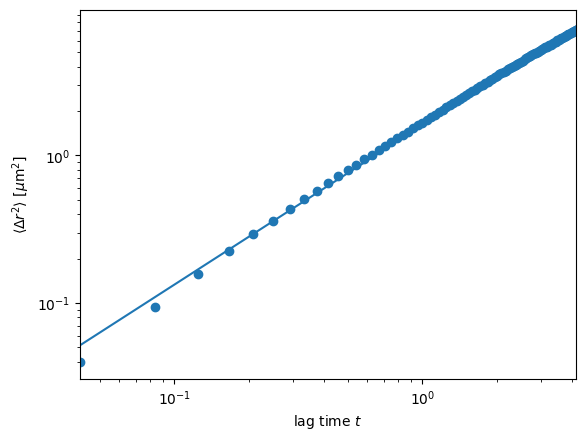

,n,A
msd,1.08024,1.602365


In [28]:
plt.figure()
plt.ylabel(r'$\langle \Delta r^2 \rangle$ [$\mu$m$^2$]')
plt.xlabel('lag time $t$');
tp.utils.fit_powerlaw(em)  # performs linear best fit in log space, plots]